# 00 — Data Audit & Validation Setup (LendingClub)

## Goal
This notebook performs a **Model Risk-style data audit** before any modeling.

We will:
- verify dataset structure and time coverage
- define a **policy-compliant** feature set (pre-origination only)
- define the **PD target** using closed outcomes only
- justify an **out-of-time (OOT)** split
- quantify **missingness** and potential **data leakage**
- produce artifacts that can go directly into the validation report

**Key principle:** strong validation starts with strong data governance.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RAW_LOAN_CSV, RAW_DICTIONARY_XLSX,
    DATE_COL, STATUS_COL, TARGET_COL,
    TRAIN_START, TRAIN_END, OOT_START, OOT_END,
    DEFAULT_STATUSES, NONDEFAULT_STATUSES,
    NUM_FEATURES, CAT_FEATURES, ENGINEERED_FEATURES,
    POST_ORIGINATION_COLS
)

from src.data.load_raw import load_raw_loans
from src.utils.checks import leakage_candidates

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Load dataset (memory-safe)

We load only:
- underwriting-time fields (candidate PD model inputs)
- a small set of post-origination fields used later for LGD/EAD proxies (not model inputs)

This reduces memory footprint and prevents accidental leakage.

In [2]:
df = load_raw_loans()
print("Loaded shape (usecols):", df.shape)
df.head()

Loaded shape (usecols): (2260668, 29)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_prncp,recoveries,last_pymnt_amnt,application_type
0,2500,2500,36 months,13.56,84.92,C,C1,10+ years,RENT,55000.0,Not Verified,2018-12-01,Current,debt_consolidation,18.24,0.0,Apr-2001,1.0,9.0,1.0,4341,10.3,34.0,2386.02,167.02,113.98,0.0,84.92,Individual
1,30000,30000,60 months,18.94,777.23,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,2018-12-01,Current,debt_consolidation,26.52,0.0,Jun-1987,0.0,13.0,1.0,12315,24.2,44.0,29387.75,1507.11,612.25,0.0,777.23,Individual
2,5000,5000,36 months,17.97,180.69,D,D1,6 years,MORTGAGE,59280.0,Source Verified,2018-12-01,Current,debt_consolidation,10.51,0.0,Apr-2011,0.0,8.0,0.0,4599,19.1,13.0,4787.21,353.89,212.79,0.0,180.69,Individual
3,4000,4000,36 months,18.94,146.51,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,2018-12-01,Current,debt_consolidation,16.74,0.0,Feb-2006,0.0,10.0,0.0,5468,78.1,13.0,3831.93,286.71,168.07,0.0,146.51,Individual
4,30000,30000,60 months,16.14,731.78,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,2018-12-01,Current,debt_consolidation,26.35,0.0,Dec-2000,0.0,12.0,0.0,829,3.6,26.0,29339.02,1423.21,660.98,0.0,731.78,Individual


## Column inventory and data types

Validation requires knowing:
- which fields exist in our working dataset
- data types and parse success (especially dates)

In [3]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 29 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   loan_amnt            2260668 non-null  int64         
 1   funded_amnt          2260668 non-null  int64         
 2   term                 2260668 non-null  str           
 3   int_rate             2260668 non-null  float64       
 4   installment          2260668 non-null  float64       
 5   grade                2260668 non-null  str           
 6   sub_grade            2260668 non-null  str           
 7   emp_length           2113761 non-null  str           
 8   home_ownership       2260668 non-null  str           
 9   annual_inc           2260664 non-null  float64       
 10  verification_status  2260668 non-null  str           
 11  issue_d              2260668 non-null  datetime64[us]
 12  loan_status          2260668 non-null  str           
 13  purpose 

In [4]:
pd.DataFrame({"column": df.columns, "dtype": [str(t) for t in df.dtypes]})

,column,dtype
0,loan_amnt,int64
1,funded_amnt,int64
2,term,str
3,int_rate,float64
4,installment,float64
5,grade,str
6,sub_grade,str
7,emp_length,str
8,home_ownership,str
9,annual_inc,float64


## Time coverage and volume

Model validation in banking relies on **out-of-time (OOT)** testing:
- train on past periods
- evaluate on a future period

We confirm time coverage and origination volume by year.

In [5]:
print("issue_d min:", df[DATE_COL].min())
print("issue_d max:", df[DATE_COL].max())

df["issue_year"] = df[DATE_COL].dt.year
year_counts = df["issue_year"].value_counts().sort_index()
year_counts.tail(15)

issue_d min: 2007-06-01 00:00:00
issue_d max: 2018-12-01 00:00:00


issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134814
2014    235629
2015    421095
2016    434407
2017    443579
2018    495242
Name: count, dtype: int64

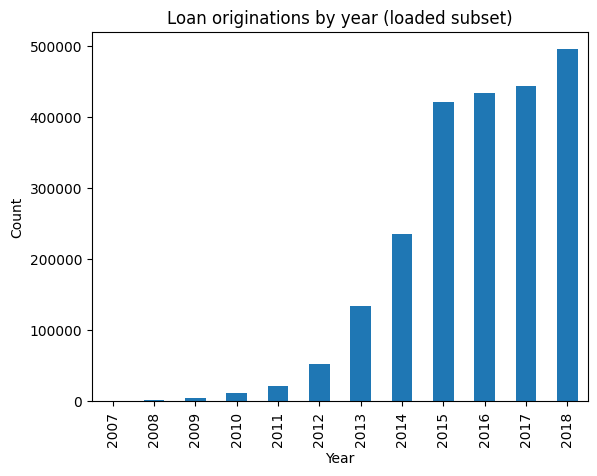

In [6]:
import matplotlib.pyplot as plt

year_counts.plot(kind="bar")
plt.title("Loan originations by year (loaded subset)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## Target definition (PD) and outcome availability

Baseline PD target uses only **closed outcomes**:
- Default = Charged Off or Default
- Non-default = Fully Paid
- Exclude Current/Late/Grace, because final outcome is not observed (label noise)

We verify counts and default rate after filtering.

In [7]:
df[STATUS_COL].value_counts().head(20)

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

**Note on `Current` loans**

`Current` means the loan is still active and its final outcome (Fully Paid vs Default/Charged Off) is not observed yet.
For a clean baseline PD label, we restrict to **closed outcomes only**.
A separate extension could treat `Late (31-120)` as a stress label, but we keep baseline strict to avoid label noise.

In [8]:
keep_status = DEFAULT_STATUSES | NONDEFAULT_STATUSES
df_closed = df[df[STATUS_COL].isin(keep_status)].copy()
df_closed[TARGET_COL] = df_closed[STATUS_COL].isin(DEFAULT_STATUSES).astype(int)

print("Closed-loans shape:", df_closed.shape)
print("Observed default rate (closed only):", df_closed[TARGET_COL].mean())
df_closed[TARGET_COL].value_counts()

Closed-loans shape: (1303638, 31)
Observed default rate (closed only): 0.20073517341470562


default_flag
0    1041952
1     261686
Name: count, dtype: int64

## OOT split sanity check

We validate:
- Train period has enough data for fitting
- OOT period has enough data for evaluation
- Default rates may differ (population drift), which is realistic and must be monitored

In [9]:
train = df_closed[(df_closed[DATE_COL] >= TRAIN_START) & (df_closed[DATE_COL] <= TRAIN_END)].copy()
oot   = df_closed[(df_closed[DATE_COL] >= OOT_START) & (df_closed[DATE_COL] <= OOT_END)].copy()

print("Train:", train.shape, "default rate:", train[TARGET_COL].mean())
print("OOT  :", oot.shape,   "default rate:", oot[TARGET_COL].mean())

Train: (1163294, 31) default rate: 0.20667260383015815
OOT  : (47191, 31) default rate: 0.14729503507024644


**Interpretation guideline**
- A shift in OOT default rate indicates **population drift**.
- Drift is not “bad” by itself; it implies we must check:
  - calibration stability
  - feature distribution stability (PSI later)
  - monitoring thresholds

**Observed in this dataset**

We see a lower observed default rate in OOT (2018) than in Train (2013–2017).
This suggests **population / underwriting drift** across time (e.g., portfolio mix or credit cycle changes).

This is realistic in banking and motivates:
- calibration checks (probability level drift)
- stability checks (feature/score PSI)
- monitoring thresholds in production

## Missingness audit (data quality)

Missingness matters because:
- high missingness increases reliance on imputation
- missingness can drift over time (model risk)
- high-missingness variables can be excluded from model inputs (governance)

In [10]:
missing_overall = (df_closed.isna().mean() * 100).sort_values(ascending=False)
missing_overall.head(30)

emp_length             5.788187
revol_util             0.062134
dti                    0.023933
inq_last_6mths         0.000077
loan_amnt              0.000000
issue_year             0.000000
application_type       0.000000
last_pymnt_amnt        0.000000
recoveries             0.000000
total_rec_prncp        0.000000
total_pymnt            0.000000
out_prncp              0.000000
total_acc              0.000000
revol_bal              0.000000
pub_rec                0.000000
open_acc               0.000000
delinq_2yrs            0.000000
earliest_cr_line       0.000000
funded_amnt            0.000000
purpose                0.000000
loan_status            0.000000
issue_d                0.000000
verification_status    0.000000
annual_inc             0.000000
home_ownership         0.000000
sub_grade              0.000000
grade                  0.000000
installment            0.000000
int_rate               0.000000
term                   0.000000
dtype: float64

In [11]:
missing_train = (train.isna().mean() * 100).sort_values(ascending=False)
missing_oot   = (oot.isna().mean() * 100).sort_values(ascending=False)

miss_compare = pd.DataFrame({
    "missing_train_%": missing_train,
    "missing_oot_%": missing_oot,
})
miss_compare["delta_oot_minus_train"] = miss_compare["missing_oot_%"] - miss_compare["missing_train_%"]
miss_compare.sort_values("delta_oot_minus_train", ascending=False).head(30)

,missing_train_%,missing_oot_%,delta_oot_minus_train
emp_length,5.878909,8.613931,2.735021
dti,0.017193,0.237333,0.220141
revol_util,0.055876,0.133500,0.077624
annual_inc,0.000000,0.000000,0.000000
loan_status,0.000000,0.000000,0.000000
total_rec_prncp,0.000000,0.000000,0.000000
total_pymnt,0.000000,0.000000,0.000000
total_acc,0.000000,0.000000,0.000000
term,0.000000,0.000000,0.000000
sub_grade,0.000000,0.000000,0.000000


### Modeling missingness policy
In the Champion model we exclude any input feature with **>30% missingness in TRAIN**.

Rationale:
- beyond this, imputation dominates the signal and increases model risk
- the model may learn missingness artifacts rather than credit risk structure

## Feature policy: allowed vs disallowed

### Allowed (pre-origination)
Underwriting-time variables at origination:
- income, DTI, delinquencies, inquiries, utilization, credit history length, etc.

### Disallowed as PD model inputs (post-origination leakage)
Examples:
- total payments received (`total_pymnt`)
- principal recovered (`total_rec_prncp`)
- recoveries (`recoveries`)
- outstanding principal (`out_prncp`)

These occur after origination and leak future information.

### Why we do NOT use geo identifiers (zip/state)
They can introduce:
- privacy/ethics concerns
- spurious correlations / fairness issues
- instability across time and policy changes

We keep the baseline focused on standard credit bureau / application variables.

### Why we do NOT use hardship/settlement fields
These are post-origination programs and contain strong outcome information (leakage).

In [12]:
print("Numeric features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)
print("Engineered features:", ENGINEERED_FEATURES)
print("Post-origination (NOT model inputs):", POST_ORIGINATION_COLS)

Numeric features: ['annual_inc', 'dti', 'int_rate', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'installment', 'funded_amnt', 'loan_amnt']
Categorical features: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type']
Engineered features: ['credit_history_length_years']
Post-origination (NOT model inputs): ['recoveries', 'total_rec_prncp', 'out_prncp', 'total_pymnt', 'last_pymnt_amnt']


## Leakage screening (keyword-based + policy-based)

We run a conservative leakage scan based on keywords to document that we checked.
Leakage prevention is then enforced by construction:
- model inputs are whitelisted
- everything else is dropped

In [13]:
leaks = leakage_candidates(df.columns.tolist())
leaks

['last_pymnt_amnt',
 'out_prncp',
 'recoveries',
 'total_pymnt',
 'total_rec_prncp']

In [14]:
allowed_set = set(NUM_FEATURES + CAT_FEATURES + ENGINEERED_FEATURES + [DATE_COL, STATUS_COL, TARGET_COL, "earliest_cr_line"])
leak_set = set(leaks)
print("Leak columns flagged:", len(leak_set))
print("Overlap (allowed vs leak):", sorted(list(allowed_set.intersection(leak_set))))

Leak columns flagged: 5
Overlap (allowed vs leak): []


## Optional feature note: FICO variables

FICO-type variables (if available in a given LendingClub extract) are strong traditional predictors for credit risk.
In this project we intentionally keep a compact underwriting feature set for clarity and validation focus.

Extension: if FICO columns are present in the raw file, we can add them and re-run the same validation protocol.

## Data dictionary (LCDataDictionary.xlsx)

Using the dictionary supports defensible “why include/exclude” decisions.

In [15]:
try:
    xls = pd.ExcelFile(RAW_DICTIONARY_XLSX)
    print("Sheets:", xls.sheet_names)
except Exception as e:
    print("Could not open Excel:", e)

Sheets: ['LoanStats', 'browseNotes', 'RejectStats']


In [16]:
# Build a dictionary lookup keyed by normalized variable names
dd = pd.read_excel(RAW_DICTIONARY_XLSX, sheet_name="browseNotes").copy()

def norm_name(s: str) -> str:
    # Normalize to compare dictionary names with CSV names
    return (
        str(s)
        .strip()
        .lower()
        .replace("-", "_")
    )

dd["var_norm"] = dd["BrowseNotesFile"].map(norm_name)

# Our project columns to document
project_cols = sorted(set(NUM_FEATURES + CAT_FEATURES + ENGINEERED_FEATURES + POST_ORIGINATION_COLS + [DATE_COL, STATUS_COL]))

# Normalize our columns
project_cols_norm = {c: norm_name(c) for c in project_cols}

# Create lookup
dd_lookup = dict(zip(dd["var_norm"], dd["Description"]))

# Build table: column -> description (if found) + role
rows = []
for c in project_cols:
    c_norm = project_cols_norm[c]
    desc = dd_lookup.get(c_norm, None)  # may be None due to naming differences (camelCase vs snake_case)
    role = (
        "MODEL_INPUT" if c in (NUM_FEATURES + CAT_FEATURES + ENGINEERED_FEATURES)
        else "POST_ORIGINATION_NOT_INPUT" if c in POST_ORIGINATION_COLS
        else "META/TARGET"
    )
    rows.append({"column": c, "role": role, "dictionary_match": desc is not None, "description": desc})

audit_table = pd.DataFrame(rows).sort_values(["role", "column"])
audit_table

,column,role,dictionary_match,description
12,issue_d,META/TARGET,False,NaN
15,loan_status,META/TARGET,False,NaN
0,annual_inc,MODEL_INPUT,False,NaN
1,application_type,MODEL_INPUT,True,Indicates whether the loan is an individual ap...
2,credit_history_length_years,MODEL_INPUT,False,NaN
3,delinq_2yrs,MODEL_INPUT,False,NaN
4,dti,MODEL_INPUT,True,A ratio calculated using the borrower’s total ...
5,emp_length,MODEL_INPUT,False,NaN
6,funded_amnt,MODEL_INPUT,False,NaN
7,grade,MODEL_INPUT,True,LC assigned loan grade


**Note on naming**
The dictionary uses a different naming convention (often camelCase), while the CSV uses snake_case.
We use normalized matching where possible. Any non-matches are documented and handled explicitly.

# Conclusions (Audit Summary)

**Dataset viability**
- Sufficient closed outcomes for PD validation.
- Time coverage supports a true OOT test (final year = 2018).

**Target definition**
- PD target defined only on closed loans (Fully Paid vs Charged Off/Default).
- Current/Late excluded to avoid unobserved outcomes.

**Leakage control**
- Post-origination variables identified (payments, recoveries, outstanding principal).
- PD model inputs will be strictly whitelisted to prevent leakage.

**Data quality**
- Missingness quantified overall and by period (Train vs OOT).
- Modeling policy: exclude input features with >30% TRAIN missingness; impute the rest deterministically.

**Next step**
- Reproduce Champion (logistic) and report Train vs OOT performance + calibration.